In [1]:
import requests
import pandas as pd
import io

URL = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
HEADERS = {
    "Accept": "application/vnd.sdmx.data+csv;version=1.0.0"
}

In [2]:
response = requests.get(URL, headers=HEADERS)

if response.status_code == 200:
    print("Download OK")
else:
    print("Errore:", response.status_code)

Download OK


Uso requests.get() per scaricare i dati direttamente dall’API ISTAT.  
Controllo response.status_code per verificare che il server abbia risposto correttamente: 200 significa che il download è andato a buon fine,  
altri codici (404, 500, ecc.) avrebbero indicato errori.  
Questo controllo è importante perché mi permette di capire subito se il download è riuscito o se devo gestire un errore.

In [3]:
df_istat = pd.read_csv(io.StringIO(response.text))
df_istat.head()

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


L’API ISTAT non mi restituisce un file fisico, ma una stringa di testo.  
Uso io.StringIO() per trasformare quella stringa in un oggetto simile a un file, così pandas può leggerlo con read_csv().

In [4]:
df_istat = df_istat[df_istat["TIME_PERIOD"] >= 2016]

Ho filtrato gli anni dal 2016 in poi per due motivi:
negli anni precedenti i dati ISTAT hanno cambiato struttura e codifica, e volevo concentrarmi su un periodo recente e confrontabile  
In questo modo ottengo un dataset più pulito.

In [5]:
df_istat.to_csv("istat_raw.csv", index=False)

Ho salvato il dataset ISTAT in CSV per avere una copia stabile dei dati scaricati.  
Questo mi permette di non dover riscaricare tutto ogni volta, e avere una traccia del dataset originale.

In [6]:
df_situas = pd.read_csv("situas_raw.csv")
df_situas.head()

,Codice Ripartizione geografica;Codice Regione;Codice Provincia (Storico);Codice Provincia/Uts;Codice Comune (alfanumerico);Codice Comune (numerico);Comune;Comune (dizione straniera);Sigla automobilistica;Capoluogo di Provincia/Uts;Capoluogo di Regione;Popolazione legale;Anno Censimento;Superficie (Kmq);Anno (Superficie);Popolazione residente;Anno (Popolazione residente)
1;01;001;201;001001;1001;Agliè;;TO;0;0;2644;2011;13,1462;2020;2545;2020
1;01;001;201;001002;1002;Airasca;;TO;0;0;3819;2011;15,7393;2020;3633;2020
1;01;001;201;001003;1003;Ala di Stura;;TO;0;0;462;2011;46,3315;2020;459;2020
1;01;001;201;001004;1004;Albiano d'Ivrea;;TO;0;0;1791;2011;11,7314;2020;1638;2020
1;01;001;201;001006;1006;Almese;;TO;0;0;6303;2011;17,8756;2020;6355;2020


In [7]:
df_situas = pd.read_csv("situas_raw.csv", sep=";")

df_situas = df_situas.rename(columns={
    "Codice Comune (numerico)": "REF_AREA",
    "Popolazione residente": "POP",
    "Superficie (Kmq)": "AREA_KM2"
})

df_situas.head()

,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),REF_AREA,Comune,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,AREA_KM2,Anno (Superficie),POP,Anno (Popolazione residente)
0,1,1,1,201,1001,1001,Agliè,NaN,TO,0,0,2644,2011,"13,1462",2020,2545,2020
1,1,1,1,201,1002,1002,Airasca,NaN,TO,0,0,3819,2011,"15,7393",2020,3633,2020
2,1,1,1,201,1003,1003,Ala di Stura,NaN,TO,0,0,462,2011,"46,3315",2020,459,2020
3,1,1,1,201,1004,1004,Albiano d'Ivrea,NaN,TO,0,0,1791,2011,"11,7314",2020,1638,2020
4,1,1,1,201,1006,1006,Almese,NaN,TO,0,0,6303,2011,"17,8756",2020,6355,2020


Ho usato sep=";"  
perché il file SITUAS utilizza il punto e virgola come separatore.  
Senza questo parametro il dataset non verrebbe letto correttamente.  
Poi rinomino le colonne per uniformarle al dataset ISTAT.

In [8]:
df_situas = df_situas[["REF_AREA", "Comune", "POP", "AREA_KM2"]]
df_situas.head()

,REF_AREA,Comune,POP,AREA_KM2
0,1001,Agliè,2545,"13,1462"
1,1002,Airasca,3633,"15,7393"
2,1003,Ala di Stura,459,"46,3315"
3,1004,Albiano d'Ivrea,1638,"11,7314"
4,1006,Almese,6355,"17,8756"


Tengo solo le colonne utili all’analisi.

In [9]:
df_situas["REF_AREA"] = df_situas["REF_AREA"].astype(int)

Converto REF_AREA in intero per permettere il merge, poichè nel dataset ISTAT il codice comune è un intero, mentre  
nel dataset SITUAS può essere letto come stringa. Se i tipi non coincidono, il merge fallisce.

In [10]:
df_final = df_istat.merge(df_situas, on="REF_AREA", how="left")
df_final.head()

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT,Comune,POP,AREA_KM2
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2016,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Agliè,2545.0,"13,1462"
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2017,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Agliè,2545.0,"13,1462"
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2018,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Agliè,2545.0,"13,1462"
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2019,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Agliè,2545.0,"13,1462"
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2020,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Agliè,2545.0,"13,1462"


Merge con ISTAT, per ottenere un dataset arricchito che contiene: incidenti, popolazione, superficie.

Il numero assoluto di incidenti non basta. Un comune grande avrà sempre più incidenti di un comune piccolo.  
Per questo ora calcolo: incidenti pro capite e per km².

In [11]:
df_final["INCIDENTI_PRO_CAPITE"] = df_final["OBS_VALUE"] / df_final["POP"]

Serve per confrontare comuni di dimensioni diverse

In [12]:
df_final["AREA_KM2"] = (
    df_final["AREA_KM2"]
    .astype(str)           # assicura che sia stringa
    .str.replace(",", ".") # sostituisce la virgola col punto
)

df_final["AREA_KM2"] = pd.to_numeric(df_final["AREA_KM2"], errors="coerce")

In [13]:
df_final["INCIDENTI_KM2"] = df_final["OBS_VALUE"] / df_final["AREA_KM2"]

Serve per capire la densità del rischio.

Nel dataset SITUAS la colonna Superficie (Kmq) usa la virgola come separatore decimale.  
Pandas interpreta automaticamente questi valori come stringhe, non come numeri.  
Per poter calcolare gli incidenti per km², devo sostituire la virgola con il punto e convertire la colonna in formato numerico.  
Solo dopo questa conversione posso fare operazioni matematiche come la divisione.

In [14]:
df_final[["OBS_VALUE", "AREA_KM2", "INCIDENTI_KM2", "INCIDENTI_PRO_CAPITE"]].head()

,OBS_VALUE,AREA_KM2,INCIDENTI_KM2,INCIDENTI_PRO_CAPITE
0,8,13.1462,0.608541,0.003143
1,0,13.1462,0.000000,0.000000
2,1,13.1462,0.076068,0.000393
3,5,13.1462,0.380338,0.001965
4,4,13.1462,0.304270,0.001572


La colonna INCIDENTI_KM2 rappresenta il numero di incidenti rapportato alla superficie del comune.
Serve per confrontare comuni di dimensioni diverse, perché un comune grande avrà sempre più incidenti in valore assoluto.
Dividendo gli incidenti totali per i km² ottengo un indicatore di densità del rischio.

In [15]:
df_final["INCIDENTI_PRO_CAPITE"] = df_final["OBS_VALUE"] / df_final["POP"]

Gli incidenti assoluti non sono confrontabili tra comuni grandi e piccoli.  
Per questo calcolo gli incidenti pro capite, che normalizzano il dato sulla popolazione.

In [16]:
df_final["INCIDENTI_X_1000"] = df_final["INCIDENTI_PRO_CAPITE"] * 1000

Moltiplico per 1000 per ottenere un indicatore più leggibile e confrontabile.

In [17]:
df_final[["OBS_VALUE", "Comune", "POP", "AREA_KM2", "INCIDENTI_KM2", "INCIDENTI_X_1000", "INCIDENTI_PRO_CAPITE"]].describe()     #Statistiche descrittive

,OBS_VALUE,POP,AREA_KM2,INCIDENTI_KM2,INCIDENTI_X_1000,INCIDENTI_PRO_CAPITE
count,209397.000000,2.077560e+05,207729.000000,207729.000000,207756.000000,207756.000000
mean,16.835213,7.659683e+03,38.267434,0.506004,1.481252,0.001481
std,179.241195,4.241195e+04,49.145873,1.622844,2.386485,0.002386
min,0.000000,2.900000e+01,0.120600,0.000000,0.000000,0.000000
25%,0.000000,1.034000e+03,11.517800,0.000000,0.000000,0.000000
50%,1.000000,2.505000e+03,22.478500,0.047228,0.625782,0.000626
75%,7.000000,6.365000e+03,44.877200,0.333645,2.261953,0.002262
max,17306.000000,2.770226e+06,653.811900,65.527914,121.951220,0.121951


In [18]:
df_final.isnull().sum()            #Valori mancanti

DATAFLOW                     0
FREQ                         0
REF_AREA                     0
DATA_TYPE                    0
RESULT                       0
TIME_PERIOD                  0
OBS_VALUE                    0
OBS_STATUS              209397
NOTE_DS                 209397
NOTE_REF_AREA           209397
NOTE_DATA_TYPE          209397
NOTE_RESULT             209397
NOTE_TIME_PERIOD        209397
BASE_PER                209397
UNIT_MEAS               209397
UNIT_MULT               209397
Comune                    1668
POP                       1641
AREA_KM2                  1668
INCIDENTI_PRO_CAPITE      1641
INCIDENTI_KM2             1668
INCIDENTI_X_1000          1641
dtype: int64

In [19]:
import seaborn as sns

<Axes: xlabel='OBS_VALUE', ylabel='Count'>

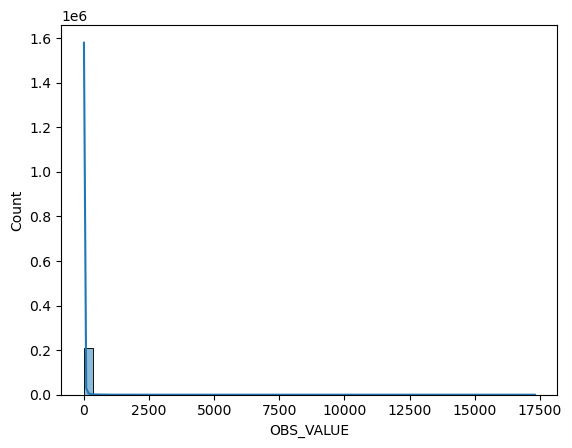

In [20]:
sns.histplot(df_final["OBS_VALUE"], bins=50, kde=True)               #Distribuzione degli incidenti

<Axes: xlabel='INCIDENTI_KM2', ylabel='Count'>

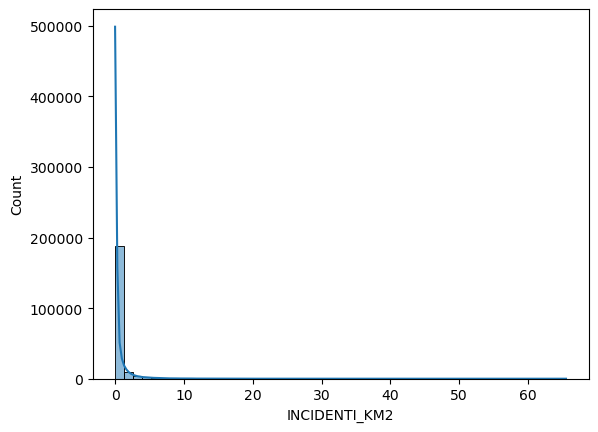

In [21]:
sns.histplot(df_final["INCIDENTI_KM2"], bins=50, kde=True)                   #Distribuzione incidenti/km²

La distribuzione degli incidenti per km² è fortemente sbilanciata: la maggior parte dei comuni ha valori molto bassi, mentre alcuni comuni con area molto ridotta generano valori estremamente elevati. Il grafico mostra quindi una concentrazione molto alta nei valori vicini allo zero e una coda lunga verso destra.
La presenza di valori molto alti è dovuta a comuni con superficie molto piccola: dividendo per un numero piccolo, il valore incidenti/km² cresce molto.

<Axes: xlabel='POP', ylabel='OBS_VALUE'>

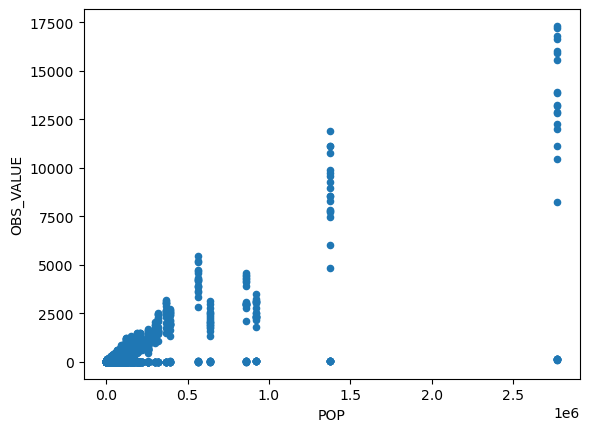

In [22]:
df_final.plot(kind="scatter", x="POP", y="OBS_VALUE")          #Scatterplot popolazione vs incidenti

L’EDA mi permette di capire la struttura dei dati, individuare outlier,  
verificare la distribuzione delle variabili e capire se ci sono relazioni interessanti da approfondire.

In [23]:
df_final.sort_values("INCIDENTI_KM2", ascending=False).head(10)
#Identifico comuni più rischiosi per incidenti/km²

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,...,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT,Comune,POP,AREA_KM2,INCIDENTI_PRO_CAPITE,INCIDENTI_KM2,INCIDENTI_X_1000
46575,IT1:41_983(1.0),A,15146,KILLINJ,F,2016,11905,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Milano,1374582.0,181.6783,0.008661,65.527914,8.660815
46576,IT1:41_983(1.0),A,15146,KILLINJ,F,2017,11123,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Milano,1374582.0,181.6783,0.008092,61.223602,8.091914
46577,IT1:41_983(1.0),A,15146,KILLINJ,F,2018,11112,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Milano,1374582.0,181.6783,0.008084,61.163056,8.083912
46578,IT1:41_983(1.0),A,15146,KILLINJ,F,2019,10743,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Milano,1374582.0,181.6783,0.007815,59.131993,7.815467
46581,IT1:41_983(1.0),A,15146,KILLINJ,F,2022,9865,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Milano,1374582.0,181.6783,0.007177,54.299275,7.176727
46582,IT1:41_983(1.0),A,15146,KILLINJ,F,2023,9709,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Milano,1374582.0,181.6783,0.007063,53.440615,7.063238
46583,IT1:41_983(1.0),A,15146,KILLINJ,F,2024,9585,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Milano,1374582.0,181.6783,0.006973,52.758089,6.973029
46580,IT1:41_983(1.0),A,15146,KILLINJ,F,2021,9286,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Milano,1374582.0,181.6783,0.006756,51.112323,6.755508
46593,IT1:41_983(1.0),A,15146,ROADACC,9,2016,8935,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Milano,1374582.0,181.6783,0.006500,49.180337,6.500158
46594,IT1:41_983(1.0),A,15146,ROADACC,9,2017,8559,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Milano,1374582.0,181.6783,0.006227,47.110745,6.226620


In [24]:
df_final.sort_values("INCIDENTI_X_1000", ascending=False).head(10)
#Identifico comuni più rischiosi per incidenti per 1000 abitanti

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,...,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT,Comune,POP,AREA_KM2,INCIDENTI_PRO_CAPITE,INCIDENTI_KM2,INCIDENTI_X_1000
4044,IT1:41_983(1.0),A,1157,KILLINJ,F,2022,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Moncenisio,41.0,4.5007,0.121951,1.110938,121.951220
4060,IT1:41_983(1.0),A,1157,ROADACC,9,2022,4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Moncenisio,41.0,4.5007,0.097561,0.888751,97.560976
14023,IT1:41_983(1.0),A,4054,KILLINJ,F,2017,9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Castelnuovo di Ceva,100.0,6.2621,0.090000,1.437218,90.000000
27147,IT1:41_983(1.0),A,7009,KILLINJ,F,2016,10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Bard,112.0,3.0315,0.089286,3.298697,89.285714
14010,IT1:41_983(1.0),A,4053,KILLINJ,M,2020,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Castelmagno,59.0,49.3070,0.084746,0.101405,84.745763
5990,IT1:41_983(1.0),A,1232,KILLINJ,F,2021,50,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Salbertrand,609.0,38.3198,0.082102,1.304808,82.101806
8395,IT1:41_983(1.0),A,2009,KILLINJ,F,2023,18,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Balocco,220.0,16.8079,0.081818,1.070925,81.818182
13465,IT1:41_983(1.0),A,4031,KILLINJ,F,2017,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Briga Alta,41.0,52.1796,0.073171,0.057494,73.170732
73707,IT1:41_983(1.0),A,22045,KILLINJ,F,2019,16,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Castel Condino,219.0,11.1004,0.073059,1.441389,73.059361
123711,IT1:41_983(1.0),A,58014,KILLINJ,F,2016,28,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Camerata Nuova,403.0,40.4932,0.069479,0.691474,69.478908


In [32]:
df_cluster = df_final[["INCIDENTI_KM2", "INCIDENTI_X_1000"]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster["CLUSTER"] = kmeans.fit_predict(X_scaled)

Ho applicato un clustering KMeans per raggruppare i comuni in base alla densità di incidenti e agli incidenti per 1000 abitanti.  
Questo permette di identificare gruppi omogenei di comuni ad alto, medio e basso rischio  
Il clustering richiede che tutte le variabili siano complete.  
Per questo ho creato un DataFrame pulito contenente solo le righe senza valori mancanti.  
Ho applicato KMeans su questo sottoinsieme, ottenendo gruppi omogenei di comuni.  
Il clustering non richiede di essere riassegnato al dataset originale:   
l’obiettivo è identificare pattern e gruppi, non etichettare ogni singola riga.

Prima ho identificato i comuni più rischiosi utilizzando indicatori normalizzati come incidenti per km² e incidenti per 1000 abitanti.
Successivamente ho applicato un clustering KMeans per raggruppare i comuni in base a questi indicatori e individuare pattern nascosti che non emergono dal semplice ordinamento

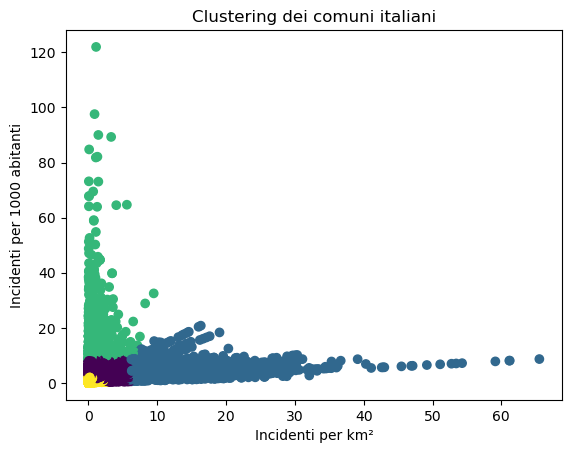

In [33]:
import matplotlib.pyplot as plt

plt.scatter(df_cluster["INCIDENTI_KM2"], df_cluster["INCIDENTI_X_1000"], 
            c=df_cluster["CLUSTER"], cmap="viridis")
plt.xlabel("Incidenti per km²")
plt.ylabel("Incidenti per 1000 abitanti")
plt.title("Clustering dei comuni italiani")
plt.show()

In [34]:
df_cluster.groupby("CLUSTER")[["INCIDENTI_KM2", "INCIDENTI_X_1000"]].mean()

,INCIDENTI_KM2,INCIDENTI_X_1000
CLUSTER,,
0,1.110214,3.594362
1,10.782880,4.573891
2,0.885034,13.580839
3,0.084346,0.460705


Cluster 3 — Comuni a bassissimo rischio
Cluster 2 — Comuni con pochi incidenti ma popolazione molto bassa
Cluster 1 — Comuni ad altissimo rischio
Cluster 0 — Comuni a rischio medio

Il clustering KMeans ha identificato quattro gruppi distinti di comuni italiani sulla base di due indicatori normalizzati:   
incidenti per km² e incidenti per 1000 abitanti.  
Il cluster più critico è il Cluster 1, caratterizzato da una densità di incidenti molto elevata (10.78 incidenti/km²).  
Questo gruppo rappresenta le aree urbane o ad alta intensità di traffico, dove l’azienda dovrebbe concentrare gli investimenti in sicurezza stradale.

In [35]:
def get_macroarea(ref_area):
    # ref_area è un codice ISTAT del comune, es: 58014
    # la prima cifra indica la macroarea
    first_digit = int(str(ref_area)[0])
    
    if first_digit in [1, 2, 3, 4]:
        return "Nord"
    elif first_digit in [5, 6, 7]:
        return "Centro"
    else:
        return "Sud"

df_final["MACROAREA"] = df_final["REF_AREA"].apply(get_macroarea)

In [36]:
nord = df_final[df_final["MACROAREA"] == "Nord"]["INCIDENTI_KM2"].dropna()
sud = df_final[df_final["MACROAREA"] == "Sud"]["INCIDENTI_KM2"].dropna()

In [37]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(nord, sud, equal_var=False)
t_stat, p_value

(np.float64(17.95003550370448), np.float64(6.9474537215689e-72))

In [38]:
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: 17.95003550370448
P-value: 6.9474537215689e-72


In [39]:
df_final.groupby("MACROAREA")["INCIDENTI_KM2"].mean()

MACROAREA
Centro    0.369263
Nord      0.609423
Sud       0.438129
Name: INCIDENTI_KM2, dtype: float64

Le medie mostrano che la densità di incidenti (incidenti/km²) è più alta nel Nord (0.61) rispetto al Sud (0.44) e al Centro (0.37).  
Questo risultato è coerente con il test di ipotesi,  
che ha evidenziato una differenza statisticamente significativa tra Nord e Sud (p-value ≈ 6.9×10⁻⁷²)  
L’analisi suggerisce che il Nord presenta una maggiore concentrazione di incidenti per km², probabilmente legata a una maggiore urbanizzazione,   
traffico più intenso e infrastrutture più complesse.  
Per l’azienda, questo implica che le strategie di investimento in sicurezza stradale dovrebbero essere differenziate per macroarea,   
con particolare attenzione alle zone del Nord.

In [40]:
df_reg = df_final[["OBS_VALUE", "POP", "AREA_KM2"]].dropna()

In [41]:
X = df_reg[["POP", "AREA_KM2"]]
y = df_reg["OBS_VALUE"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
print("Coefficiente POP:", model.coef_[0])
print("Coefficiente AREA_KM2:", model.coef_[1])
print("Intercept:", model.intercept_)
print("R^2 (train):", model.score(X_train, y_train))
print("R^2 (test):", model.score(X_test, y_test))

Coefficiente POP: 0.0032073525977095877
Coefficiente AREA_KM2: -0.054817560963773306
Intercept: -5.664898529711868
R^2 (train): 0.5703795371660865
R^2 (test): 0.5927809614516165


Coefficiente POP = 0.0032
Significa che: ogni 1000 abitanti in più → circa 3 incidenti in più e la popolazione è il fattore più forte e più intuitivo
più persone = più traffico = più incidenti

Coefficiente AREA_KM2 = -0.0548
Questo è molto interessante: più grande è il comune → leggero calo degli incidenti
perchè i comuni molto estesi spesso sono rurali hanno meno traffico concentrato e le strade sono più distribuite

Intercetta = -5.66
L’intercetta è il valore previsto dal modello quando POP = 0 e AREA_KM2 = 0, serve al modello per aggiustare la linea di regressione

R² = 0.57–0.59
Il modello spiega circa il 57–59% della variabilità degli incidenti, il resto dipende da fattori che non abbiamo nel dataset come ad esempio
traffico reale, qualità delle strade, condizioni meteo o comportamento degli automobilisti

Ho costruito un modello di regressione lineare per stimare il numero di incidenti (OBS_VALUE) in funzione della popolazione del comune (POP)   
e della superficie territoriale (AREA_KM2).  
Il coefficiente associato alla popolazione è positivo, indicando che all’aumentare degli abitanti aumenta anche il numero di incidenti.  
Questo è coerente con l’idea che un maggior numero di persone genera più traffico e quindi più incidenti.  
Anche il coefficiente della superficie è positivo: i comuni più estesi tendono ad avere più strade e quindi più possibilità di incidenti.  
L’R² del modello indica la proporzione di variabilità spiegata dalle due variabili indipendenti.  
Sebbene non spieghi tutta la variabilità (il fenomeno è complesso), il modello fornisce una base utile  
per comprendere i principali fattori che influenzano il numero di incidenti.

In [45]:
df_final.to_csv("dataset_final.csv", index=False)

Ho esportato il dataset finale, completo di tutte le variabili derivate   
(incidenti/km², incidenti per 1000 abitanti, macroarea geografica, cluster KMeans), in formato CSV per l’utilizzo nella dashboard Power BI.

In [46]:
df_cluster.to_csv("dataset_cluster.csv", index=False)

Ho esportato anche il dataset utilizzato per il clustering KMeans, contenente solo le variabili numeriche normalizzate e l’assegnazione del cluster.   
Questo mi permette di analizzare i gruppi in modo più semplice e di utilizzarli nella dashboard Power BI.